<a href="https://colab.research.google.com/github/freyebeans/ASU-assignments/blob/main/MAT422/HW1.4/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT422 Section 1.4 Principal Component Analysis
Michael Bishop

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.4.1 Sigular Value Decomposition
Given a matrix *A*, we can find matrices *U*, $\mathit{\Sigma}$, and *V* such that $A = \mathit{U\Sigma}V^T$, *U* and *V* have orthonormal columns, and the sigular values $\sigma$ in $\mathit{\Sigma}$ indicate how much each direction contributes to *A*.

In [2]:
A = np.array([
    [1,2,4,2,5],
    [-2,5,1,0,-3],
    [1,0,2,-2,1],
    [0,2,-5,1,2]
])

U, s, VT = np.linalg.svd(A, full_matrices=False)
S = np.diag(s)
reconstruction = U @ S @ VT

print("A =")
print(A)
print("Singular values =", s)
print("U =")
print(U)
print("Sigma =")
print(S)
print("V.T =")
print(VT)

A =
[[ 1  2  4  2  5]
 [-2  5  1  0 -3]
 [ 1  0  2 -2  1]
 [ 0  2 -5  1  2]]
Singular values = [7.4208 6.2422 5.8537 2.1682]
U =
[[ 0.8937 -0.0765  0.4059 -0.1752]
 [-0.2003 -0.9302  0.2981  0.0752]
 [ 0.2763 -0.0526 -0.2145  0.9354]
 [-0.2913  0.355   0.8369  0.2979]]
Sigma =
[[7.4208 0.     0.     0.    ]
 [0.     6.2422 0.     0.    ]
 [0.     0.     5.8537 0.    ]
 [0.     0.     0.     2.1682]]
V.T =
[[ 0.2116  0.0274  0.7255  0.1271  0.6419]
 [ 0.2774 -0.6559 -0.4993  0.0492  0.4911]
 [-0.0692  0.6793 -0.4598  0.3549  0.4432]
 [ 0.2813  0.2865 -0.1127 -0.887   0.1981]]


In [3]:
print("U.T * U =")
print(U.T @ U)
print("V.T * V =")
print(VT @ VT.T)

U.T * U =
[[ 1.  0. -0. -0.]
 [ 0.  1.  0. -0.]
 [-0.  0.  1.  0.]
 [-0. -0.  0.  1.]]
V.T * V =
[[ 1. -0.  0. -0.]
 [-0.  1.  0.  0.]
 [ 0.  0.  1.  0.]
 [-0.  0.  0.  1.]]


In [4]:
print("Reconstrution error ||A - U Sigma V.T||_F = ", np.linalg.norm(A - reconstruction, ord="fro"))
print("Is the reconstruction accurate?", np.allclose(A, reconstruction))

Reconstrution error ||A - U Sigma V.T||_F =  4.093143143314544e-15
Is the reconstruction accurate? True


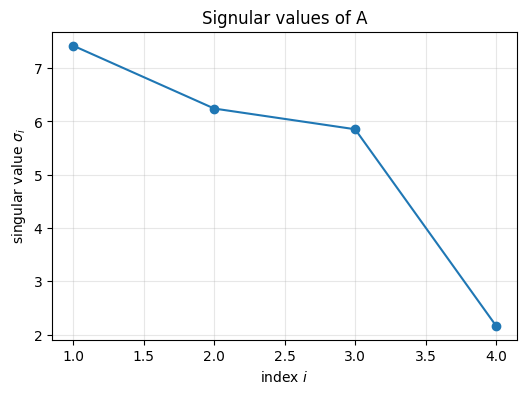

In [5]:
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(s) + 1), s, marker="o")
plt.xlabel("index $i$")
plt.ylabel("singular value $\\sigma _i$")
plt.title("Signular values of A")
plt.grid(True, alpha = 0.3)
plt.show()

Because a large singular value indicates that the corresponding direction has a large effect on the matrix and small singular values indicate less impact, SVD can be use for approximating or compressing a matrix.
## 1.4.2 Low-Rank Matrix Approximations
For a matrix *A* we can make a rank-k approximation by keeping only the first k singular value and vectors in the singular value decomposition. This k-rank approximation $A_k$ is simpler than *A* and captures the stongest patterns in *A*.

In [6]:
def k_rank_approx(U, s, VT, k):
    return U[:, :k] @ np.diag(s[:k]) @ VT[:k, :]

errors = []
for k in range(1, len(s) + 1):
    Ak = k_rank_approx(U,s,VT,k)
    err = np.linalg.norm(A - Ak, ord="fro")
    errors.append(err)
    print(f"Rank-{k} approximation:")
    print(Ak)
    print("error =",err)
    print("matrix rank =",np.linalg.matrix_rank(Ak))
    print()


Rank-1 approximation:
[[ 1.4036  0.1816  4.8112  0.8432  4.2567]
 [-0.3146 -0.0407 -1.0784 -0.189  -0.9541]
 [ 0.4339  0.0561  1.4873  0.2607  1.3159]
 [-0.4575 -0.0592 -1.5683 -0.2749 -1.3875]]
error = 8.827931062658097
matrix rank = 1

Rank-2 approximation:
[[ 1.2712  0.4949  5.0497  0.8197  4.0221]
 [-1.9252  3.7679  1.8208 -0.4748 -3.8058]
 [ 0.3428  0.2716  1.6514  0.2445  1.1546]
 [ 0.1571 -1.5127 -2.6747 -0.1658 -0.2993]]
error = 6.242375266049864
matrix rank = 2

Rank-3 approximation:
[[ 1.1068  2.1088  3.9572  1.663   5.0753]
 [-2.0458  4.9533  1.0184  0.1446 -3.0323]
 [ 0.4296 -0.5811  2.2286 -0.2011  0.5982]
 [-0.1817  1.8149 -4.9272  1.5729  1.872 ]]
error = 2.1681783813779294
matrix rank = 3

Rank-4 approximation:
[[ 1.  2.  4.  2.  5.]
 [-2.  5.  1. -0. -3.]
 [ 1. -0.  2. -2.  1.]
 [-0.  2. -5.  1.  2.]]
error = 4.093143143314544e-15
matrix rank = 4



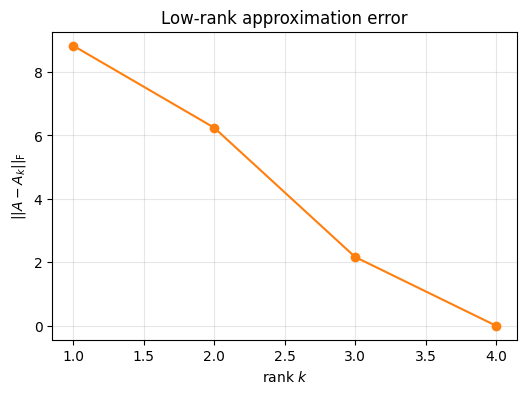

In [7]:
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(errors) + 1), errors, marker="o", color="tab:orange")
plt.xlabel("rank $k$")
plt.ylabel("$||A-A_k||_\\text{F}$")
plt.title("Low-rank approximation error")
plt.grid(True, alpha = 0.3)
plt.show()

As you can see the error of the approximation decrease as k increases. When k equals the rank of *A*, the approximation is equal to *A*.
## 1.4.3 Principal Componenet Analysis
Provided a data matrix *X*, we can use principal component analysis to find the directions along which the data varies most. We can find these principal component directions by using singular value decomposition as the columns of *V* or the rows of $V^T$ (from $X = \mathit{U\Sigma}V^T$).

In [8]:
X = np.array([
    [3.9,-3.5],
    [3.6,-3.7],
    [2.8,-1.4],
    [2.5,-1.0],
    [3.2,-3.0],
    [1.8,-1.0],
    [1.7,-2.0],
    [2.8,-1.9],
    [2.1,-2.0],
    [2.5,-3.0],
    [3.8,-3.3],
    [1.9,-2.2]
])

mean = X.mean(axis=0)
X_centered = X - mean
U_pca, s_pca, VT_pca = np.linalg.svd(X_centered, full_matrices=False)
scores = X_centered @ VT_pca.T
variance = (s_pca**2) / (len(X) - 1)
variance_ratio = variance / variance.sum()

print("feature means =", mean)
print("principal directions (rows of V.T) =")
print(VT_pca)
print("singular values =", s_pca)
print("explained variance =", variance)
print("explained variance ratio =", variance_ratio)
print("first 5 PCA scores =")
print(scores[:5])

feature means = [ 2.7167 -2.3333]
principal directions (rows of V.T) =
[[-0.6041  0.7969]
 [ 0.7969  0.6041]]
singular values = [3.7883 1.4738]
explained variance = [1.3047 0.1974]
explained variance ratio = [0.8686 0.1314]
first 5 PCA scores =
[[-1.6446  0.2382]
 [-1.6227 -0.1217]
 [ 0.6934  0.6302]
 [ 1.1934  0.6328]
 [-0.8233 -0.0176]]


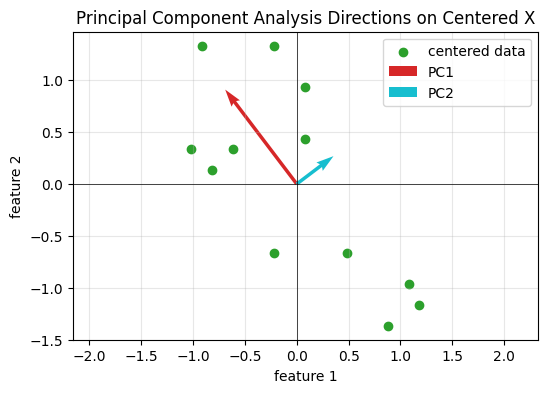

In [9]:
pc1 = VT_pca[0] * s_pca[0] / np.sqrt(len(X)-1)
pc2 = VT_pca[1] * s_pca[1] / np.sqrt(len(X)-1)

plt.figure(figsize=(6,4))
plt.scatter(X_centered[:,0],X_centered[:,1],color="tab:green",label="centered data")
plt.quiver(*np.zeros(2),*pc1, angles="xy", scale_units="xy", scale=1, color="tab:red", label="PC1")
plt.quiver(*np.zeros(2),*pc2, angles="xy", scale_units="xy", scale=1, color="tab:cyan", label="PC2")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Principal Component Analysis Directions on Centered X")
plt.grid(True, alpha = 0.3)
plt.axis("equal")
plt.legend()
plt.show()

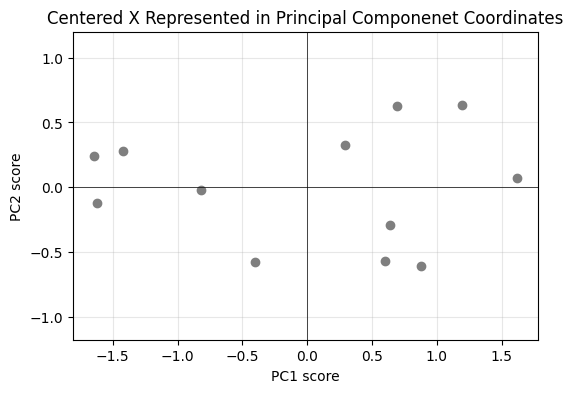

In [10]:
plt.figure(figsize=(6,4))
plt.scatter(scores[:,0],scores[:,1],color="tab:gray")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title("Centered X Represented in Principal Componenet Coordinates")
plt.xlabel("PC1 score")
plt.ylabel("PC2 score")
plt.grid(True, alpha = 0.3)
plt.axis("equal")
plt.show()

The majority of the variance in *X* occurs along the dierction of the first principle component. Projecting *X* onto PC1 and PC2 rotates the data in such a way that most of the variance occurs along the x-axis.
## Reflection and Rubric Checklist
- I ran the notebook in its entirety without error.
- I covered SVF, low-rank approximation, and PCA.
- The examples clearly demonstrate the concepts.
- I explained each concpet before and after the code.
- I organized the notebook in a logical way with headers and readable code.
- I changed and extended at least one example so that the notebook reflects my own work.
- I saved the notebook from Google Colab directly to GitHub as per course instructions.